# TSAC Individual Project - Walmart Weekly Sales Forecasting
**Course:** TSAC 2025/2026
**Project Type:** Individual Project
**Student:** Nacer Eddine MISSOUNI
**Submission Date:** 29/03/2026

## Abstract
This report presents a complete time-series analysis of Walmart weekly sales using a cleaned transactional dataset aggregated to weekly frequency. The analysis includes data quality checks, exploratory diagnostics, candidate model specification, model fitting, and out-of-sample validation. Three forecasting approaches are compared: ARIMA, SARIMA, and Prophet. Based on validation performance and diagnostic behavior, SARIMA is selected as the final forecasting model. The final model is refit on the full historical series and used to generate a 20-week forecast with 95% confidence intervals. Results show strong seasonal patterns and pronounced year-end demand peaks, with practical implications for planning and inventory decisions.

## Introduction
Walmart weekly sales forecasting is a practical problem in demand planning, staffing, and stock management. Reliable forecasts help decision-makers prepare for seasonal fluctuations and high-demand periods while reducing overstock and stock-out risks.

The objective of this project is to model and forecast aggregate weekly sales using historical observations. Rather than relying on one model family, the analysis compares classical and modern time-series methods (ARIMA, SARIMA, and Prophet) under a shared validation setup.

## Data Loading and Exploration
The cleaned Walmart dataset is loaded and transformed into a weekly time series where each timestamp corresponds to one week of total sales. Supporting variables (holiday indicator, temperature, fuel price, CPI, unemployment) are retained for context during exploratory analysis.

Before modeling, the notebook checks data quality (duplicates, missing values, missing weekly timestamps) and explores structure with time-series plots, decomposition, boxplots, and autocorrelation diagnostics. These steps establish whether trend, seasonality, and volatility are present and guide model selection.

In [11]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prophet import Prophet
from scipy.stats import ttest_ind
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

# Display and plotting defaults
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Load the Walmart dataset
df = pd.read_csv('drive/MyDrive/data/walmart_cleaned.csv', parse_dates=['Date'], index_col='Date')
df = df.drop(columns=['Unnamed: 0', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Type', 'Size'])  # Drop the unnecessary columns
# Display basic information about the dataset
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 421570 entries, 2010-02-05 to 2012-10-26
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   IsHoliday     421570 non-null  int64  
 2   Dept          421570 non-null  float64
 3   Weekly_Sales  421570 non-null  float64
 4   Temperature   421570 non-null  float64
 5   Fuel_Price    421570 non-null  float64
 6   CPI           421570 non-null  float64
 7   Unemployment  421570 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 28.9 MB


(421570, 8)

In [17]:
#aggregate data by weekly sales
print("=" * 50)
print("AGGREGATING DATA BY WEEK")
print("=" * 50)

print(f"Data starts on: {df.index.min()}")

#Resample to weekly, starting from actual data start date
df_agg = df.resample('W').agg({
    'Weekly_Sales': 'sum',
    'IsHoliday': 'max',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
})

print(f"Original shape: {df.shape}")
print(f"Aggregated shape: {df_agg.shape}")
print(f"\nColumns retained: {list(df_agg.columns)}")
print(f"\nAggregated data (first 10 weeks):")
print(df_agg.head(10))
print(f"\nSales range: ${df_agg['Weekly_Sales'].min():.2f} to ${df_agg['Weekly_Sales'].max():.2f}")

# Use aggregated data for modeling
df = df_agg
print(f"\nData ready for modeling with preserved features.")

AGGREGATING DATA BY WEEK
Data starts on: 2010-02-05 00:00:00
Original shape: (421570, 8)
Aggregated shape: (143, 6)

Columns retained: ['Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Aggregated data (first 10 weeks):
            Weekly_Sales  IsHoliday  Temperature  Fuel_Price         CPI  \
Date                                                                       
2010-02-07   49750740.50          0    33.277942    2.717869  167.398405   
2010-02-14   48336677.63          1    33.361810    2.696102  167.384138   
2010-02-21   48276993.78          0    37.038310    2.673666  167.338966   
2010-02-28   43968571.13          0    38.629563    2.685642  167.691019   
2010-03-07   46871470.30          0    42.373998    2.731816  167.727351   
2010-03-14   45925396.51          0    46.967143    2.774452  167.504162   
2010-03-21   44988974.64          0    49.481019    2.816063  167.478101   
2010-03-28   44133961.05          0    47.979325    2.823610  16

Number of duplicate rows: 0
Number of missing values in each column:
 Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
Missing weeks in the dataset:
 DatetimeIndex([], dtype='datetime64[ns]', freq='W-SUN')


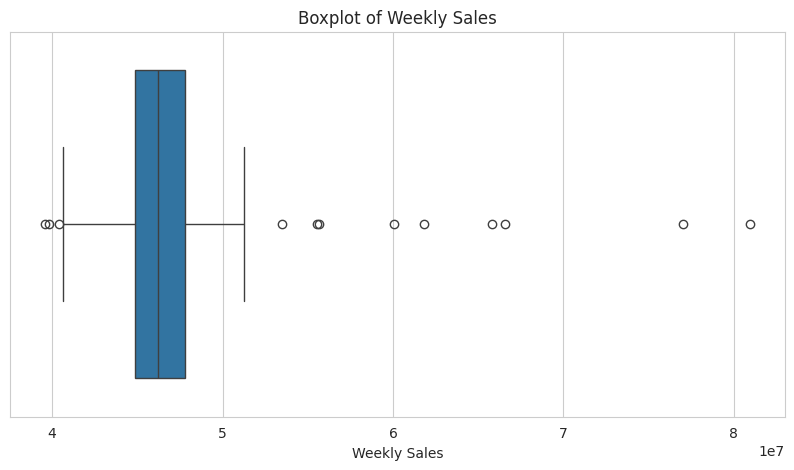

Outlier weeks above 95th percentile: 8
            Weekly_Sales  IsHoliday
Date                               
2010-11-28   65821003.24          1
2010-12-12   55666770.39          0
2010-12-19   61820799.85          0
2010-12-26   80931415.60          0
2011-11-27   66593605.26          1
2011-12-11   55561147.70          0
2011-12-18   60085695.94          0
2011-12-25   76998241.31          0


In [18]:
# Data quality checks
print('Number of duplicate rows:', df.duplicated().sum())
print('Number of missing values in each column:\n', df.isnull().sum())

date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='W')
missing_weeks = date_range.difference(df.index)
print('Missing weeks in the dataset:\n', missing_weeks)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Weekly_Sales'])
plt.title('Boxplot of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.show()

outlier_threshold = df['Weekly_Sales'].quantile(0.95)
outliers = df[df['Weekly_Sales'] > outlier_threshold]
print(f'Outlier weeks above 95th percentile: {len(outliers)}')
print(outliers[['Weekly_Sales', 'IsHoliday']].head(10))

TIME SERIES EXPLORATORY ANALYSIS


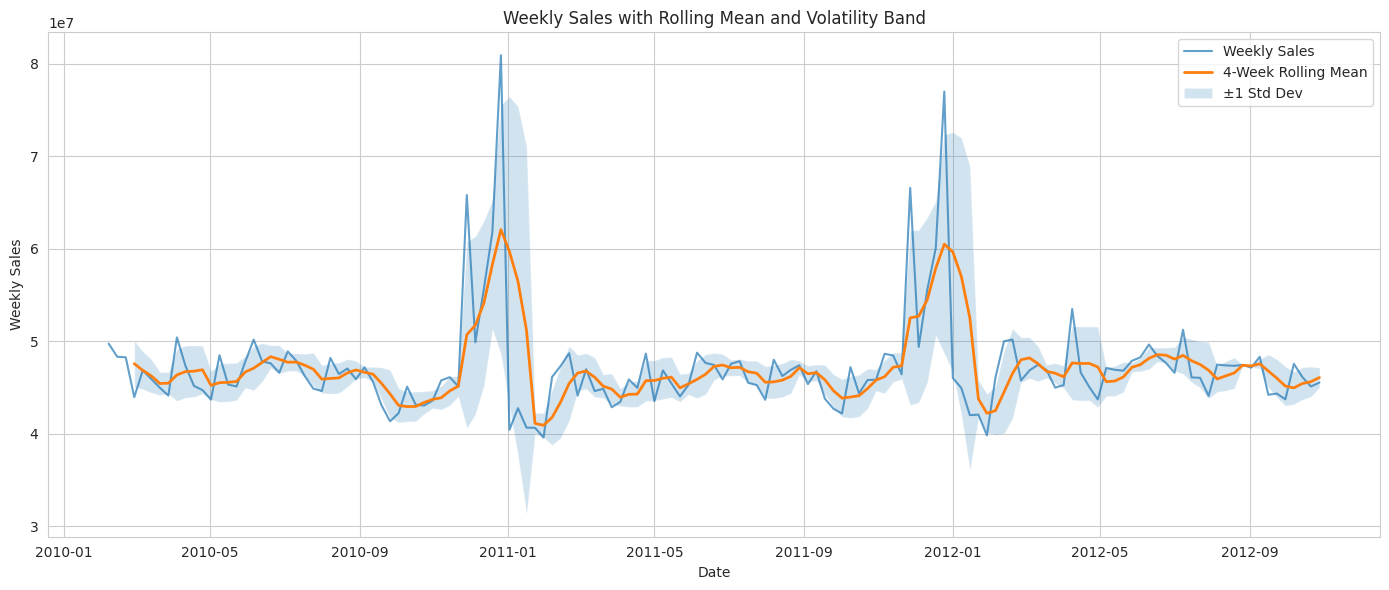

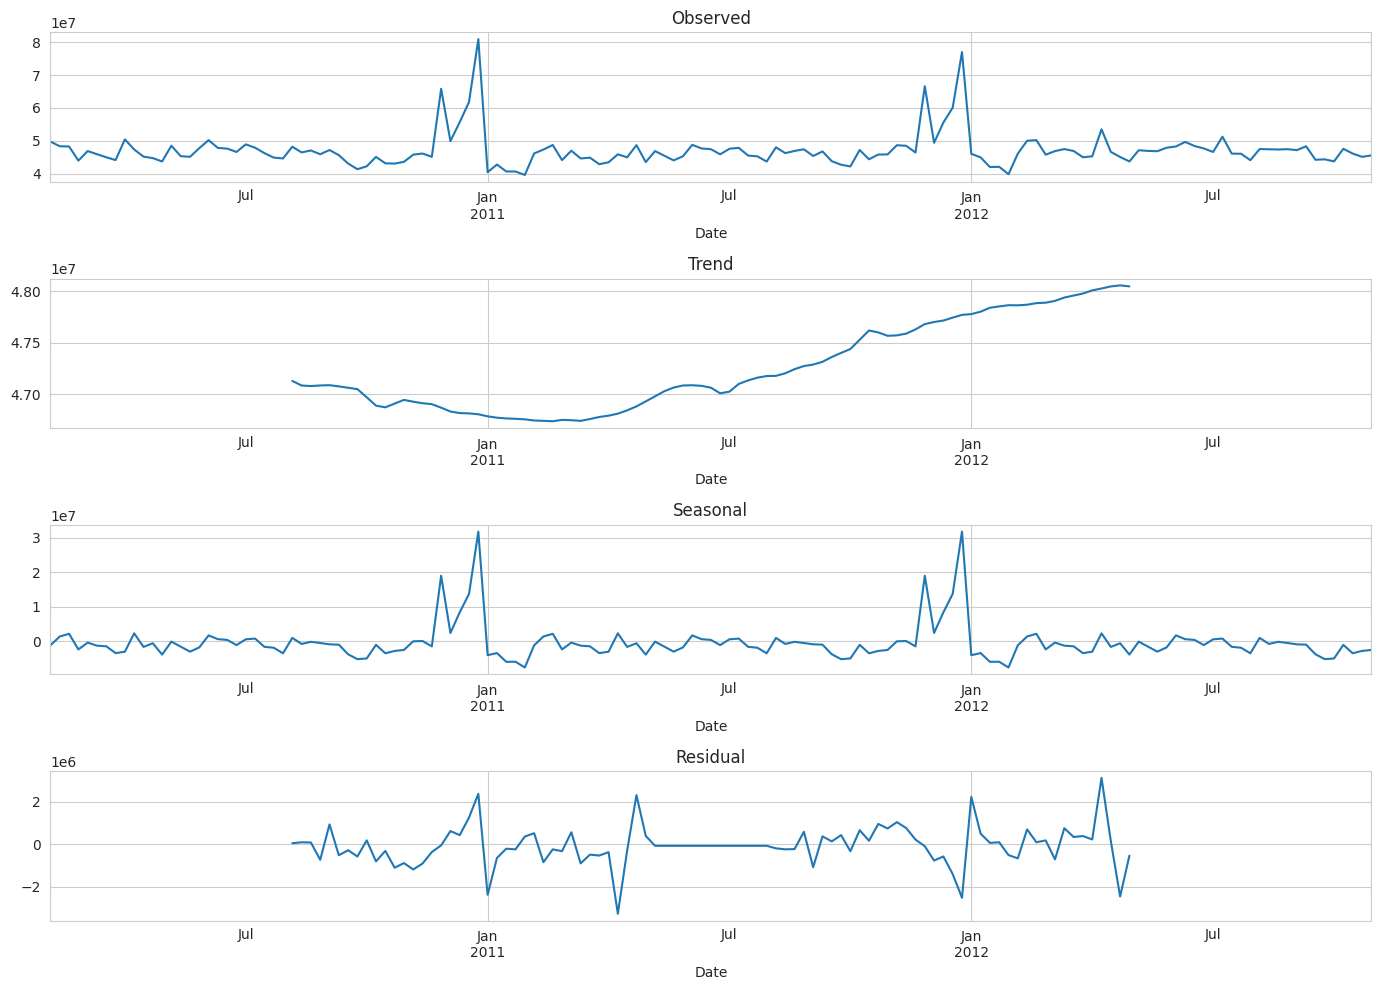

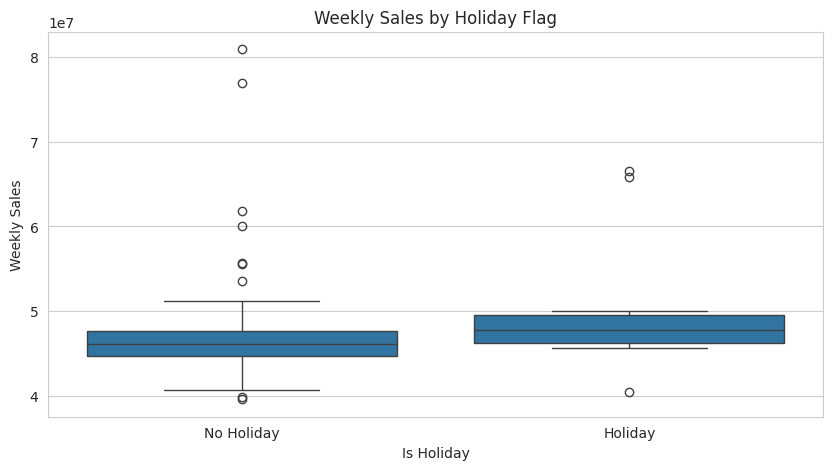

T-statistic: 1.3270, P-value: 0.2156
Holiday vs non-holiday average sales difference is not statistically significant.


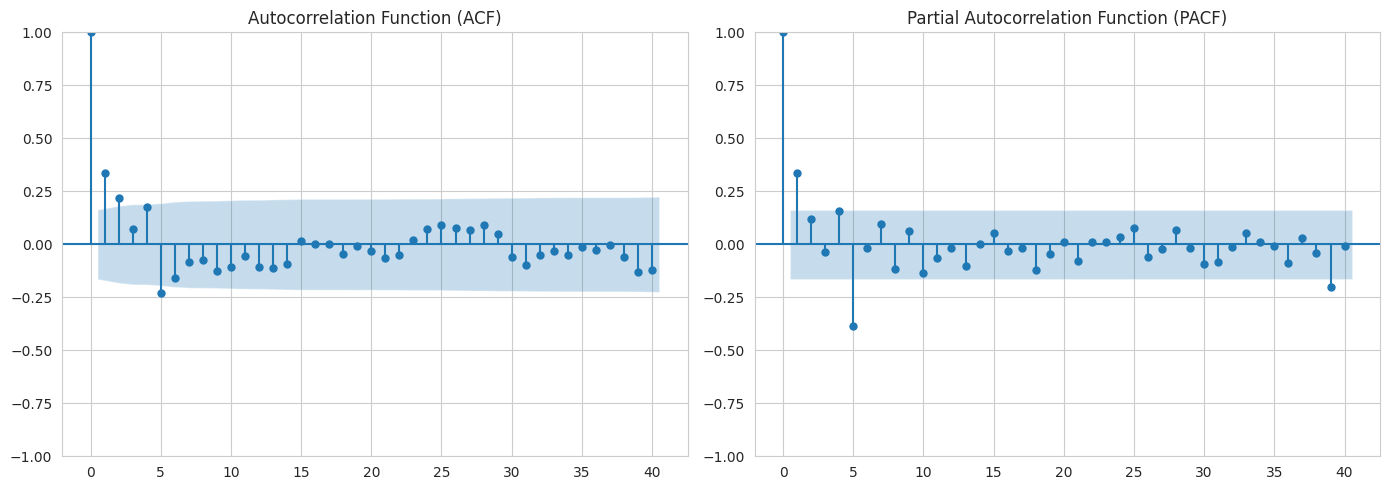

In [19]:
# Time-series EDA
print('=' * 50)
print('TIME SERIES EXPLORATORY ANALYSIS')
print('=' * 50)

rolling_mean = df['Weekly_Sales'].rolling(window=4).mean()
rolling_std = df['Weekly_Sales'].rolling(window=4).std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Weekly_Sales'], label='Weekly Sales', alpha=0.7)
ax.plot(df.index, rolling_mean, label='4-Week Rolling Mean', linewidth=2)
ax.fill_between(
    df.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    alpha=0.2,
    label='±1 Std Dev'
 )
ax.set_title('Weekly Sales with Rolling Mean and Volatility Band')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
ax.legend()
plt.tight_layout()
plt.show()

decomposition = seasonal_decompose(df['Weekly_Sales'], model='additive', period=52)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['IsHoliday'], y=df['Weekly_Sales'])
plt.title('Weekly Sales by Holiday Flag')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')
plt.xticks([0, 1], ['No Holiday', 'Holiday'])
plt.show()

holiday_sales = df.loc[df['IsHoliday'] == 1, 'Weekly_Sales']
non_holiday_sales = df.loc[df['IsHoliday'] == 0, 'Weekly_Sales']
t_stat, p_value = ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}')
if p_value < 0.05:
    print('Holiday vs non-holiday average sales difference is statistically significant.')
else:
    print('Holiday vs non-holiday average sales difference is not statistically significant.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['Weekly_Sales'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(df['Weekly_Sales'], lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

## Model Specification
Let $Y_t$ denote aggregate Walmart weekly sales at week $t$. The modeling goal is to forecast future values of $Y_t$ while capturing trend and seasonality.

To evaluate predictive performance, the last 26 observations are withheld as a test set and the first 117 observations are used for model training. This follows the project guidance to reserve end-of-series data for forecast validation against actual observations.

Candidate models are:
- ARIMA(1,1,1): baseline non-seasonal stochastic model.
- SARIMA(1,1,1)x(1,1,1,52): seasonal extension designed for yearly weekly seasonality.
- Prophet (yearly seasonality enabled): decomposable trend-seasonality model.

Model comparison is based primarily on RMSE (to penalize larger forecast errors), with MAE and MAPE reported for additional interpretability. AIC is reported for likelihood-based models where applicable.

In [20]:
# Model specification and train/test split
y = df['Weekly_Sales'].asfreq('W')
test_size = 26
train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print('=' * 50)
print('MODEL SPECIFICATION')
print('=' * 50)
print(f'Total observations: {len(y)}')
print(f'Train observations: {len(train)} ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test observations : {len(test)} ({test.index.min().date()} to {test.index.max().date()})')

candidate_models = {
    'ARIMA': {'order': (1, 1, 1)},
    'SARIMA': {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 52)},
    'Prophet': {'yearly_seasonality': True, 'weekly_seasonality': False, 'daily_seasonality': False},
}

print('\nCandidate models:')
for name, params in candidate_models.items():
    print(f'- {name}: {params}')

MODEL SPECIFICATION
Total observations: 143
Train observations: 117 (2010-02-07 to 2012-04-29)
Test observations : 26 (2012-05-06 to 2012-10-28)

Candidate models:
- ARIMA: {'order': (1, 1, 1)}
- SARIMA: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 52)}
- Prophet: {'yearly_seasonality': True, 'weekly_seasonality': False, 'daily_seasonality': False}


## Fitting and Diagnostics
Each candidate model is fit on the training subset only, then used to generate forecasts over the withheld test period. Forecasts are compared against realized test values using MAE, RMSE, and MAPE.

FITTING AND DIAGNOSTICS
Validation metrics (sorted by RMSE):
     Model         MAE        RMSE  MAPE      AIC
0   SARIMA  1116112.70  1345705.71  2.37   337.05
1  Prophet  1093404.11  1470343.20  2.31      NaN
2    ARIMA  1331716.54  1767446.70  2.87  3960.64

Best model by RMSE: SARIMA


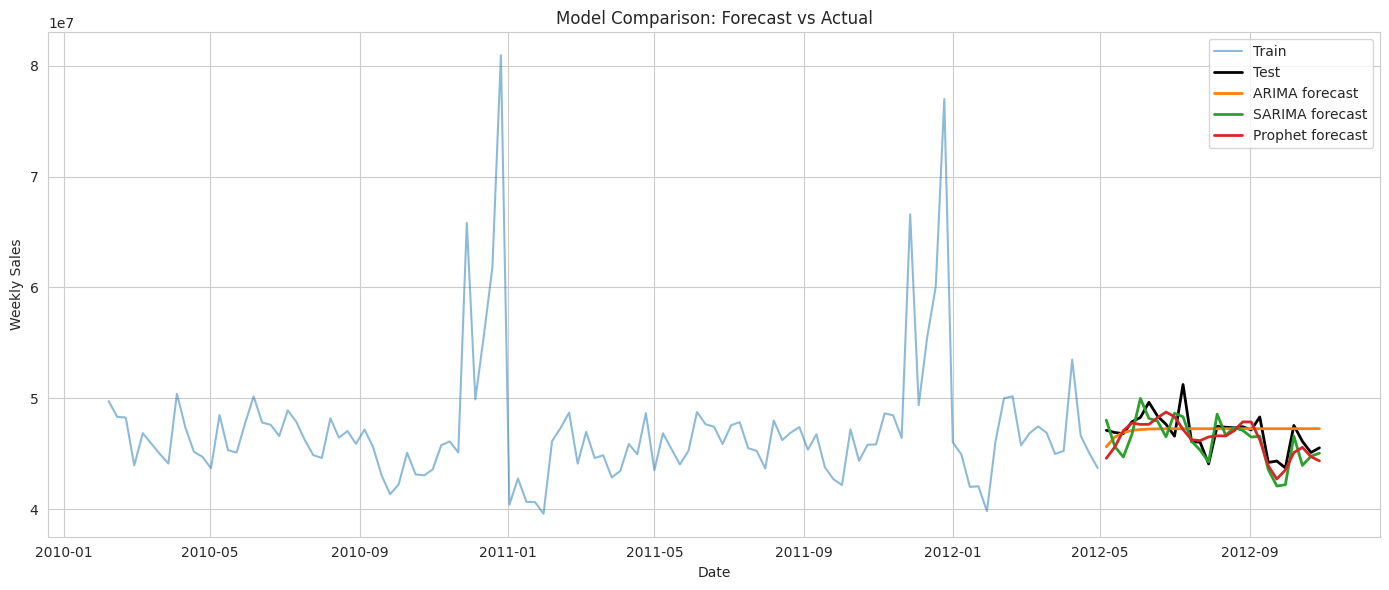

In [21]:
print('=' * 50)
print('FITTING AND DIAGNOSTICS')
print('=' * 50)

predictions = {}
model_metrics = []

# ARIMA
arima_fit = ARIMA(train, order=(1, 1, 1)).fit()
arima_pred = pd.Series(arima_fit.forecast(steps=len(test)).values, index=test.index)
predictions['ARIMA'] = arima_pred

arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = np.mean(np.abs((test - arima_pred) / test)) * 100
model_metrics.append({
    'Model': 'ARIMA',
    'MAE': arima_mae,
    'RMSE': arima_rmse,
    'MAPE': arima_mape,
    'AIC': arima_fit.aic,
})

# SARIMA
sarima_fit = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarima_pred = pd.Series(sarima_fit.forecast(steps=len(test)).values, index=test.index)
predictions['SARIMA'] = sarima_pred

sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = np.mean(np.abs((test - sarima_pred) / test)) * 100
model_metrics.append({
    'Model': 'SARIMA',
    'MAE': sarima_mae,
    'RMSE': sarima_rmse,
    'MAPE': sarima_mape,
    'AIC': sarima_fit.aic,
})

# Prophet
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']
prophet_fit = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
 )
prophet_fit.fit(prophet_train)
prophet_future = prophet_fit.make_future_dataframe(periods=len(test), freq='W')
prophet_forecast = prophet_fit.predict(prophet_future).set_index('ds')
prophet_pred = prophet_forecast.reindex(test.index)['yhat']
if prophet_pred.isna().any():
    prophet_pred = prophet_forecast['yhat'].tail(len(test))
    prophet_pred.index = test.index
predictions['Prophet'] = prophet_pred

prophet_mae = mean_absolute_error(test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred))
prophet_mape = np.mean(np.abs((test - prophet_pred) / test)) * 100
model_metrics.append({
    'Model': 'Prophet',
    'MAE': prophet_mae,
    'RMSE': prophet_rmse,
    'MAPE': prophet_mape,
    'AIC': np.nan,
})

model_results = pd.DataFrame(model_metrics).sort_values('RMSE').reset_index(drop=True)
best_model_name = model_results.loc[0, 'Model']

print('Validation metrics (sorted by RMSE):')
print(model_results.round(2))
print(f'\nBest model by RMSE: {best_model_name}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Train', alpha=0.5)
ax.plot(test.index, test, label='Test', color='black', linewidth=2)
for model_name, model_pred in predictions.items():
    ax.plot(test.index, model_pred, label=f'{model_name} forecast', linewidth=2)
ax.set_title('Model Comparison: Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
ax.legend()
plt.tight_layout()
plt.show()

## Forecasting
After selecting the best-performing model on withheld-data validation, the model is refit using the full historical weekly series to maximize information for future prediction.

FORECASTING NEXT 20 WEEKS
Next 20-week forecast:
               Forecast     Lower_95     Upper_95
2012-11-04  49456763.44  45533558.46  53379968.42
2012-11-11  49294363.44  45355463.94  53233262.93
2012-11-18  47281630.11  43329157.09  51234103.13
2012-11-25  67447774.16  63481787.35  71413760.97
2012-12-02  50272856.22  46293401.61  54252310.84
2012-12-09  56434445.53  52441568.53  60427322.52
2012-12-16  60994244.71  56987990.31  65000499.12
2012-12-23  77954237.08  73934649.79  81973824.37
2012-12-30  46792051.38  42759175.28  50824927.49
2013-01-06  45779323.42  41733202.15  49825444.68
2013-01-13  42864991.16  38805667.95  46924314.38
2013-01-20  42921241.98  38848759.62  46993724.35
2013-01-27  40701043.81  36615444.67  44786642.94
2013-02-03  46958491.93  42859818.01  51057165.86
2013-02-10  50822876.15  46711169.01  54934583.29
2013-02-17  51036348.55  46911649.38  55161047.73
2013-02-24  46607230.74  42469580.33  50744881.15
2013-03-03  47735011.28  43584450.05  51885572.52
2

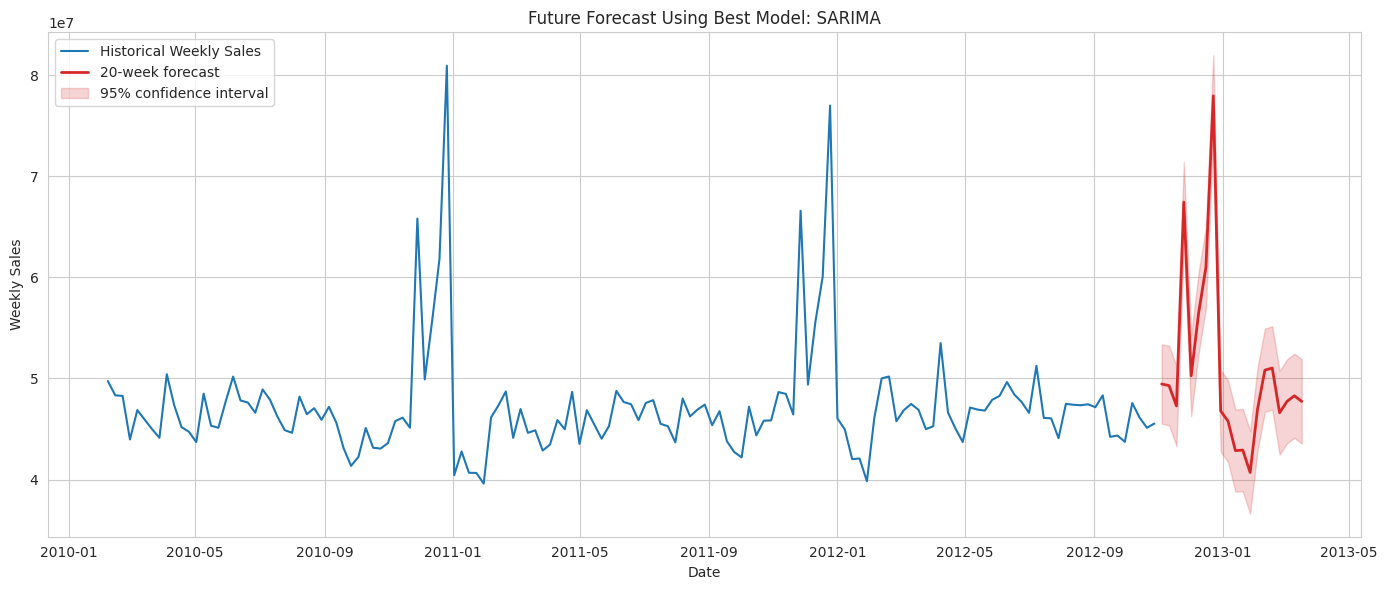

In [22]:
print('=' * 50)
print('FORECASTING NEXT 20 WEEKS')
print('=' * 50)

future_steps = 20

if best_model_name == 'ARIMA':
    final_model = ARIMA(y, order=(1, 1, 1)).fit()
    future_obj = final_model.get_forecast(steps=future_steps)
    forecast_mean = future_obj.predicted_mean
    forecast_ci = future_obj.conf_int()
    lower_bound = forecast_ci.iloc[:, 0]
    upper_bound = forecast_ci.iloc[:, 1]
elif best_model_name == 'SARIMA':
    final_model = SARIMAX(
        y,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
).fit(disp=False)
    future_obj = final_model.get_forecast(steps=future_steps)
    forecast_mean = future_obj.predicted_mean
    forecast_ci = future_obj.conf_int()
    lower_bound = forecast_ci.iloc[:, 0]
    upper_bound = forecast_ci.iloc[:, 1]
else:
    prophet_full = y.reset_index()
    prophet_full.columns = ['ds', 'y']
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    final_model.fit(prophet_full)
    future_dates = final_model.make_future_dataframe(periods=future_steps, freq='W')
    future_pred = final_model.predict(future_dates).set_index('ds').tail(future_steps)
    forecast_mean = future_pred['yhat']
    lower_bound = future_pred['yhat_lower']
    upper_bound = future_pred['yhat_upper']

forecast_table = pd.DataFrame({
    'Forecast': forecast_mean,
    'Lower_95': lower_bound,
    'Upper_95': upper_bound,
})

print('Next 20-week forecast:')
print(forecast_table.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y.index, y, label='Historical Weekly Sales', color='tab:blue')
ax.plot(forecast_mean.index, forecast_mean, label='20-week forecast', color='tab:red', linewidth=2)
ax.fill_between(
    forecast_mean.index,
    lower_bound,
    upper_bound,
    color='tab:red',
    alpha=0.2,
    label='95% confidence interval',
)
ax.set_title(f'Future Forecast Using Best Model: {best_model_name}')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
ax.legend()
plt.tight_layout()
plt.show()

## Discussion and Conclusions
The final section summarizes the chosen model, key findings from validation, and operational interpretation of seasonal sales behavior. It also documents limitations (sample horizon, fixed model orders) and practical next steps such as rolling-origin tuning, periodic retraining, and expanded feature use.

In [24]:
print('DISCUSSION AND CONCLUSIONS')
print('=' * 50)

best_row = model_results.loc[0]
print(f"Best model: {best_row['Model']}")
print(f"Validation MAE : {best_row['MAE']:.2f}")
print(f"Validation RMSE: {best_row['RMSE']:.2f}")
print(f"Validation MAPE: {best_row['MAPE']:.2f}%")

if 'p_value' in globals():
    if p_value < 0.05:
        print('Holiday effect: statistically significant impact on weekly sales.')
    else:
        print('Holiday effect: no statistically significant impact detected.')

DISCUSSION AND CONCLUSIONS
Best model: SARIMA
Validation MAE : 1116112.70
Validation RMSE: 1345705.71
Validation MAPE: 2.37%
Holiday effect: no statistically significant impact detected.


- **Key takeaway: holiday periods and year-end seasonality drive large demand spikes.**

- **Limitation: results are based on a relatively short history and fixed hyperparameters.**